In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output
import ipywidgets as widgets

# State to store points
points = []
output = widgets.Output()

def update_view():
    with output:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.set_title("Centroid Plot")
        ax.grid(True, linestyle='--', alpha=0.6)

        if points:
            pts = np.array(points)
            ax.scatter(pts[:, 0], pts[:, 1], color='blue', label='Points')

            n = len(points)
            sum_x = np.sum(pts[:, 0])
            sum_y = np.sum(pts[:, 1])
            cx, cy = sum_x / n, sum_y / n

            ax.scatter(cx, cy, color='red', marker='x', s=150, linewidths=3, label='Centroid')
            ax.legend()
            plt.show()

            print(f"--- Detailed Calculation (n = {n} points) ---")
            for i, (px, py) in enumerate(points):
                print(f"Point {i+1}: ({px:.2f}, {py:.2f})")

            print(f"\nSum of X = {' + '.join([f'{p[0]:.2f}' for p in points])} = {sum_x:.2f}")
            print(f"Sum of Y = {' + '.join([f'{p[1]:.2f}' for p in points])} = {sum_y:.2f}")

            print(f"\nCentroid X (Cx) = Sum(X) / n = {sum_x:.2f} / {n} = {cx:.4f}")
            print(f"Centroid Y (Cy) = Sum(Y) / n = {sum_y:.2f} / {n} = {cy:.4f}")
            print(f"Final Centroid Position: ({cx:.4f}, {cy:.4f})")
        else:
            ax.text(5, 5, "Use sliders to add points", ha='center')
            plt.show()
            print("No points added yet.")

x_slider = widgets.FloatSlider(min=0, max=10, step=0.1, description='X:')
y_slider = widgets.FloatSlider(min=0, max=10, step=0.1, description='Y:')
add_button = widgets.Button(description="Add Point", button_style='success')
reset_button = widgets.Button(description="Reset", button_style='danger')

def on_add_clicked(b):
    points.append((x_slider.value, y_slider.value))
    update_view()

def on_reset_clicked(b):
    global points
    points = []
    update_view()

add_button.on_click(on_add_clicked)
reset_button.on_click(on_reset_clicked)

ui = widgets.VBox([widgets.HBox([x_slider, y_slider, add_button, reset_button]), output])
display(ui)
update_view()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# State Variables
state = {
    'X_interactive': None,
    'centroids': None,
    'labels': None,
    'iteration': 0,
    'history_sse': [],
    'converged_at': None,
    'buffer_steps': 0
}

def initialize_data():
    """Generates a new 'beautiful' dataset with a bridge and resets the algorithm."""
    cluster_a = np.random.normal(loc=[2, 2], scale=0.5, size=(10, 2))
    cluster_b = np.random.normal(loc=[8, 8], scale=0.5, size=(10, 2))
    bridge = np.array([[3.5, 3.5], [4.5, 4.5], [5.5, 5.5], [6.5, 6.5]])
    state['X_interactive'] = np.vstack([cluster_a, cluster_b, bridge])
    reset_algo(None)

def reset_algo(b):
    """Resets the algorithm state to step 0."""
    state['centroids'] = np.array([[0.2, 0.8], [0.8, 0.2]])
    state['labels'] = np.zeros(state['X_interactive'].shape[0], dtype=int)
    state['iteration'] = 0
    state['history_sse'] = []
    state['converged_at'] = None
    state['buffer_steps'] = 0
    next_button.disabled = False
    next_button.description = "Next Step (Iterate)"
    run_kmeans_step(None)

output_area = widgets.Output()

def run_kmeans_step(b):
    with output_area:
        X = state['X_interactive']

        # 1. Assignment Step
        distances = np.linalg.norm(X[:, np.newaxis] - state['centroids'], axis=2)
        state['labels'] = np.argmin(distances, axis=1)

        # 2. Calculation of Cost (SSE)
        total_sse = 0
        sse_details = []
        for k in range(2):
            cluster_points = X[state['labels'] == k]
            if len(cluster_points) > 0:
                sq_dist = np.sum((cluster_points - state['centroids'][k])**2)
                total_sse += sq_dist
                sse_details.append(f"Cluster {k+1} SSE: {sq_dist:.4f} ({len(cluster_points)} points)")
            else:
                sse_details.append(f"Cluster {k+1} is empty.")

        state['history_sse'].append(total_sse)

        if b is not None and b.description.startswith("Next"):
            state['iteration'] += 1

        # 3. Visualization
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='#f9f9f9')

        colors = ['#3498db', '#2ecc71']
        for k in range(2):
            idx = state['labels'] == k
            ax1.scatter(X[idx, 0], X[idx, 1], c=colors[k], label=f'Group {k+1}', s=70, alpha=0.8, edgecolors='white')
            ax1.scatter(state['centroids'][k, 0], state['centroids'][k, 1], c='red', marker='X', s=250, edgecolors='black', label=f'Centroid {k+1}', zorder=10)

        status = "Iterating..." if state['converged_at'] is None else f"STABILITY CHECK ({state['buffer_steps']}/3)"
        ax1.set_title(f"Step {state['iteration']}: {status}", fontsize=14, fontweight='bold')
        ax1.set_xlim(-1, 11); ax1.set_ylim(-1, 11)
        ax1.grid(True, linestyle='--', alpha=0.3)

        ax2.plot(range(1, len(state['history_sse']) + 1), state['history_sse'], marker='o', color='#e74c3c', linewidth=2)
        ax2.set_title(f"Cost Progress (SSE): {total_sse:.2f}", fontsize=14, fontweight='bold')
        ax2.set_xlabel("Iteration Step")
        ax2.set_ylabel("Total SSE")
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # 4. Explicit Text Output for Math/SSE Breakdown
        print(f"\n--- MATHEMATICAL BREAKDOWN (STEP {state['iteration']}) ---")
        for detail in sse_details: print(detail)
        print(f"Current Total SSE = {total_sse:.4f}")

        print("\n--- COST HISTORY ---")
        for i, val in enumerate(state['history_sse']):
            print(f"Step {i}: SSE = {val:.4f}")

        # 5. Update Centroids & Stopping Logic
        if b is not None and b.description.startswith("Next"):
            new_centroids = np.array([X[state['labels'] == k].mean(axis=0) if len(X[state['labels'] == k]) > 0 else state['centroids'][k] for k in range(2)])

            if np.allclose(state['centroids'], new_centroids, atol=1e-4):
                if state['converged_at'] is None: state['converged_at'] = state['iteration']
                state['buffer_steps'] += 1
                next_button.description = f"Confirm Stability ({state['buffer_steps']}/3)"
                if state['buffer_steps'] >= 3:
                    print("\n[FINISHED] Centroids are stable. Minimum SSE reached.")
                    next_button.disabled = True
            else:
                state['centroids'] = new_centroids

# UI Setup
next_button = widgets.Button(description="Next Step (Iterate)", button_style='primary', layout=widgets.Layout(width='200px'))
randomize_button = widgets.Button(description="Randomize & Reset", button_style='warning', layout=widgets.Layout(width='200px'))

next_button.on_click(run_kmeans_step)
randomize_button.on_click(lambda b: initialize_data())

display(widgets.HBox([next_button, randomize_button]), output_area)
initialize_data()

Output()

Generated dataset with 300 samples, 2 features, and 4 true centers.
K=1: Inertia = 2812.14
K=2: Inertia = 1190.78
K=3: Inertia = 546.89
K=4: Inertia = 212.01
K=5: Inertia = 188.77
K=6: Inertia = 170.73
K=7: Inertia = 154.89
K=8: Inertia = 137.53
K=9: Inertia = 123.76
K=10: Inertia = 112.41


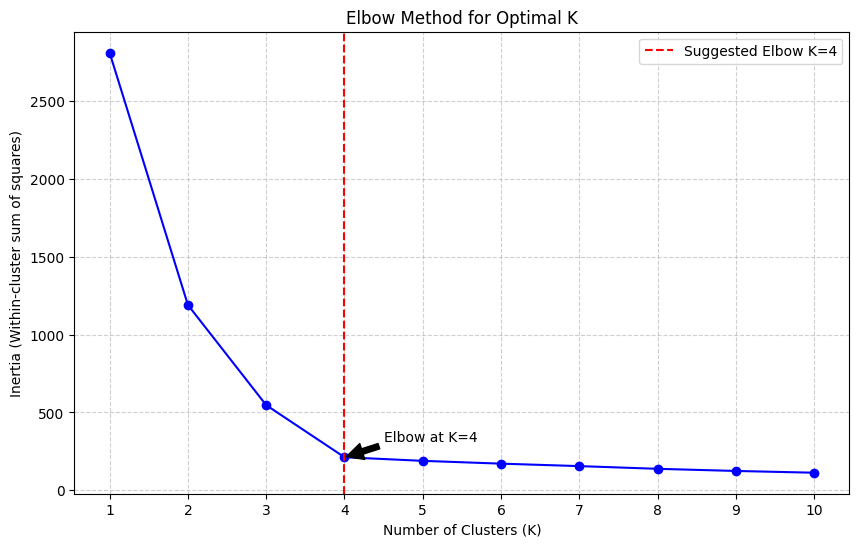


--- Explanation of Elbow Method ---
The Elbow Method is a heuristic used to determine the optimal number of clusters (K) for K-means clustering.
It involves plotting the inertia (Within-Cluster Sum of Squares - WCSS) as a function of the number of clusters (K).
Inertia measures how 'tight' the clusters are; a smaller inertia means more compact clusters.
As K increases, the inertia generally decreases because the data points are closer to their respective centroids.
The 'elbow' point on the plot is where the rate of decrease in inertia sharply changes, forming an 'elbow' shape.
This point is often considered the optimal K, as adding more clusters beyond this point does not significantly reduce the inertia, indicating diminishing returns.
Based on the plot above, visual inspection suggests the elbow is around K=4, indicating that this might be the optimal number of clusters for this dataset.


In [26]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np

# 1. Generate a sample dataset
n_samples = 300
n_features = 2
n_true_centers = 4
X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_true_centers, cluster_std=0.60, random_state=0)

print(f"Generated dataset with {n_samples} samples, {n_features} features, and {n_true_centers} true centers.")

# 2. Define a range of K values to test
k_range = range(1, 11) # Test K from 1 to 10
inertia_values = []

# 3. Run K-means for each K and store the inertia
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10) # n_init to prevent local optima
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)
    print(f"K={k}: Inertia = {kmeans.inertia_:.2f}")

# 4. Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o', linestyle='-', color='blue')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.xticks(list(k_range))
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight the elbow point (manual observation for now)
# For this dataset, the elbow is usually around K=4 or K=5
# A simple heuristic to mark potential elbow might be finding the point of maximum curvature.
# For illustrative purposes, let's assume K=4 as the elbow for this example.
# This is often done by visual inspection.

elbow_k_suggestion = 4 # Based on common datasets like make_blobs with 4 centers
plt.axvline(x=elbow_k_suggestion, color='red', linestyle='--', label=f'Suggested Elbow K={elbow_k_suggestion}')
plt.annotate(f'Elbow at K={elbow_k_suggestion}',
             xy=(elbow_k_suggestion, inertia_values[elbow_k_suggestion-1]),
             xytext=(elbow_k_suggestion + 0.5, inertia_values[elbow_k_suggestion-1] + 100),
             arrowprops=dict(facecolor='black', shrink=0.05),
             horizontalalignment='left')

plt.legend()
plt.show()

print("\n--- Explanation of Elbow Method ---")
print("The Elbow Method is a heuristic used to determine the optimal number of clusters (K) for K-means clustering.")
print("It involves plotting the inertia (Within-Cluster Sum of Squares - WCSS) as a function of the number of clusters (K).")
print("Inertia measures how 'tight' the clusters are; a smaller inertia means more compact clusters.")
print("As K increases, the inertia generally decreases because the data points are closer to their respective centroids.")
print("The 'elbow' point on the plot is where the rate of decrease in inertia sharply changes, forming an 'elbow' shape.")
print("This point is often considered the optimal K, as adding more clusters beyond this point does not significantly reduce the inertia, indicating diminishing returns.")
print(f"Based on the plot above, visual inspection suggests the elbow is around K={elbow_k_suggestion}, indicating that this might be the optimal number of clusters for this dataset.")